# Notebook used to prototype msclean parameters

In [1]:
from radioimaging.util import util
from radioimaging.evaluation import evaluation
from ska_sdp_func_python.image.cleaners import msclean
from radioimaging.visibility import ingest, residual
from ska_sdp_func_python.imaging import advise_wide_field
import numpy

cmap = "turbo"

mod_load: 0.0281524658203125
select source: 5.763070344924927
select_dd: 3.337860107421875e-06
tq: 17.838970184326172
dddesc 0: 0.0002841949462890625
tquery 0: 8.068493604660034
rtime 0: 0.011192560195922852
rdatacol 0: 0.00023508071899414062
rdd initial 0: 8.079922199249268
rchannum: 0.2030167579650879
averagechan: 5.245208740234375e-06
ruvw: 0.5525774955749512
rpol: 0.0002167224884033203
rconfig: 0.0008893013000488281
makebaselines: 0.8576037883758545
readphasecenters: 0.893435001373291
convert: 7.5276689529418945
createvis: 0.0949854850769043
Model image plate scale (arcsec) is 1.949420e+00


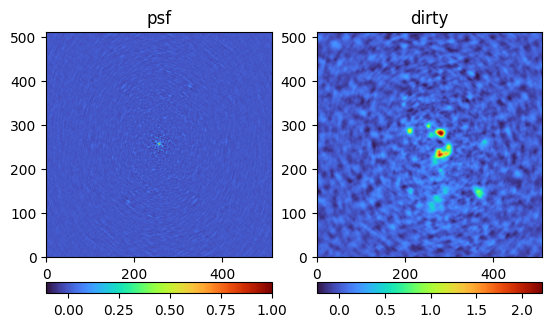

In [2]:
dataset_name = "/home/sunwang/radio-imaging/data8/LOW/SGRB_full_averaged.ms"

[vis], _ = ingest.create_visibility_from_ms(dataset_name, use_weight_spec=True, start_chan=0, end_chan=0, selected_dds=[0])
npix = 512
advice = advise_wide_field(vis, guard_band_image=3.0, delA=0.1, facets=1, oversampling_synthesised_beam=4.0)
cell_size = 9.451054227727638e-06
dirty, psf = residual.dirty_psf_from_visibilities(vis,cell_size,npix=npix,weighting="uniform", override_cellsize=False)

util.plotNImages([psf.pixels.data[0,0,:,:], dirty.pixels.data[0,0,:,:]],["psf", "dirty"], cmap=cmap)

In [309]:
scales = [1, 2, 3, 5]
fracthresh = 1e-1
niter = 20000
thresh = 1e-2
gain = 0.1

deconvolved, _ = msclean(dirty.pixels.data[0,0,:,:], psf.pixels.data[0,0,:,:], None, None, gain, thresh, niter, scales, fracthresh)

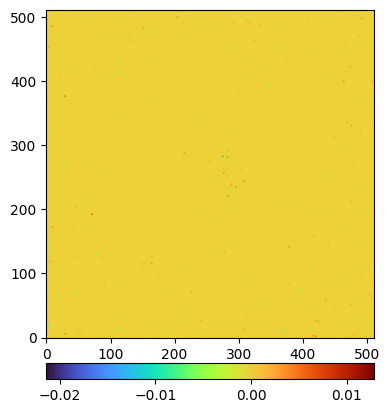

In [310]:
util.plotNImages([deconvolved],[""], cmap=cmap)
util.tofits(deconvolved, "test.fits")

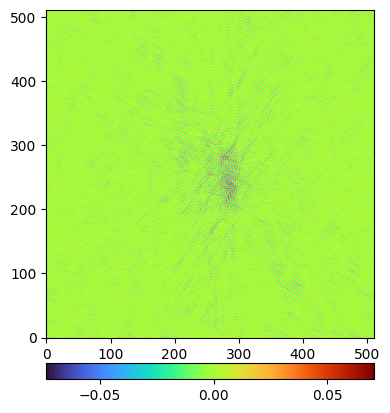

In [311]:
util.plotNImages([util.convolve2d(deconvolved, psf.pixels.data[0,0,:,:])],[""], cmap=cmap)

In [260]:
from ska_sdp_datamodels.gridded_visibility.grid_vis_model import GridData

vis_to_im = numpy.round(
        griddata.griddata_acc.griddata_wcs.sub([4]).wcs_world2pix(
            vis.frequency.data, 0
        )[0]
    ).astype("int")


NameError: name 'griddata' is not defined